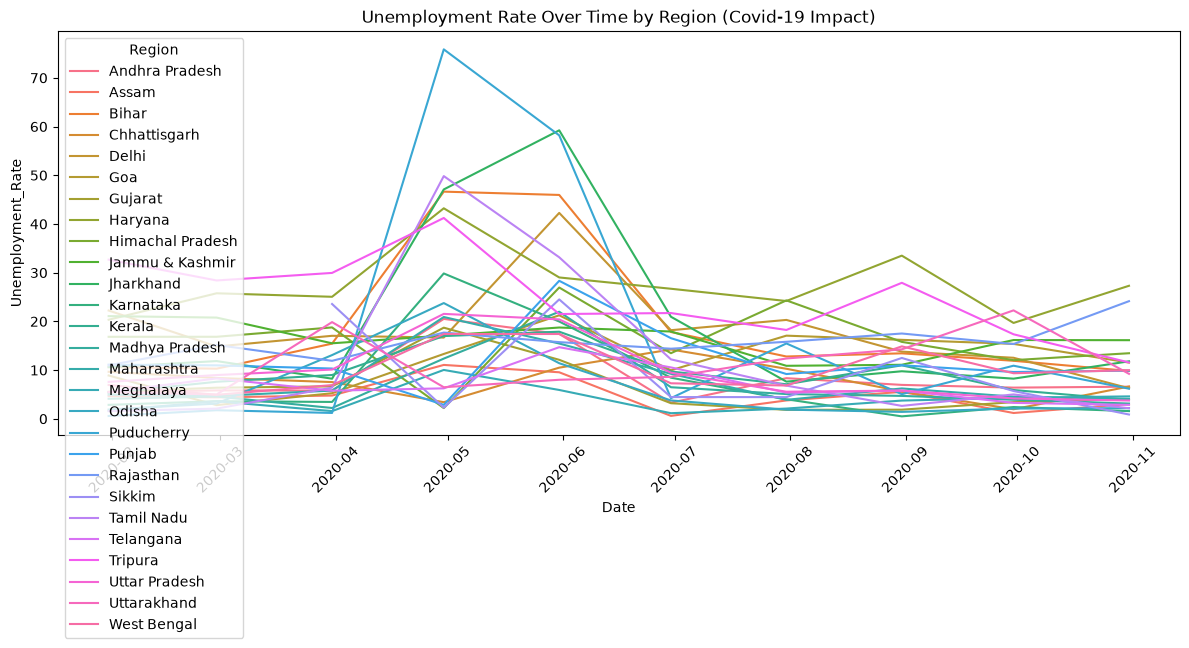

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# 1. Load the dataset
url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/unemployment.csv"
data = pd.read_csv(url)

# 2. Data Cleaning
# Clean column names (strip spaces) and rename for easier plotting
data.columns = [col.strip() for col in data.columns]
data = data.rename(columns={'Estimated Unemployment Rate (%)': 'Unemployment_Rate'})
data['Date'] = pd.to_datetime(data['Date'].str.strip(), dayfirst=True)

# 3. Visualize: Unemployment Rate Over Time
plt.figure(figsize=(12, 6))
sns.lineplot(data=data, x='Date', y='Unemployment_Rate', hue='Region')
plt.title('Unemployment Rate Over Time by Region (Covid-19 Impact)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Visualize: Interactive Sunburst Chart
# We use Region.1 (Broad group) and Region (State) to show hierarchy
fig = px.sunburst(data, 
                  path=["Region.1", "Region"], 
                  values="Unemployment_Rate", 
                  title="Unemployment Rate by Region (Broad Group vs Specific State)")
fig.show()